<a href="https://colab.research.google.com/github/zrabagheri/credit-card-fraud-detection/blob/main/multimodal_Alzheimer_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from skimage.feature import hog, graycomatrix, graycoprops
from skimage.util import img_as_ubyte

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.cross_decomposition import PLSCanonical

In [49]:
# TODO: load MRI and PET data from Google Drive
mri = load_images("/content/drive/MyDrive/MRI/")
pet = load_images("/content/drive/MyDrive/PET/")
print("MRI shape:",mri.shape)
print("PET shape:",pet.shape)

MRI shape: (300, 64, 64)
PET shape: (300, 64, 64)


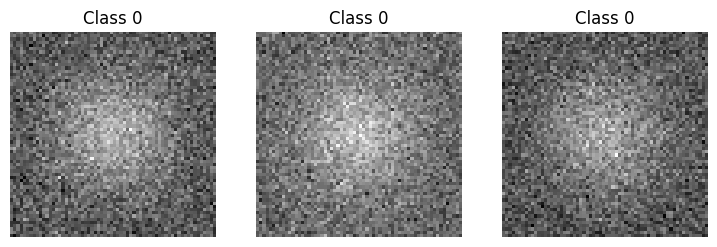

In [48]:
plt.figure(figsize=(9,3))

for i in range(3):

    plt.subplot(1,3,i+1)
    plt.imshow(mri[i],cmap="gray")
    plt.title(f"Class {labels[i]}")
    plt.axis("off")

plt.show()

mri_glcm = extract_glcm(mri)
pet_glcm = extract_glcm(pet)

In [46]:
def extract_glcm(images):

    feats=[]

    for img in images:

        img_norm=(img-img.min())/(img.max()-img.min()+1e-8)

        img_uint=img_as_ubyte(img_norm)

        glcm = graycomatrix(
            img_uint,
            distances=[1,2],
            angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
            levels=256,
            symmetric=True,
            normed=True
        )

        contrast = graycoprops(glcm,'contrast').flatten()
        energy = graycoprops(glcm,'energy').flatten()
        homogeneity = graycoprops(glcm,'homogeneity').flatten()
        correlation = graycoprops(glcm,'correlation').flatten()

        feature = np.hstack((contrast,energy,homogeneity,correlation))

        feats.append(feature)

    return np.array(feats)

mri_glcm = extract_glcm(mri)
pet_glcm = extract_glcm(pet)

In [18]:
def extract_hog(images):

    feats=[]

    for img in images:

        fd = hog(
            img,
            orientations=9,
            pixels_per_cell=(16,16),
            cells_per_block=(2,2),
            feature_vector=True
        )

        feats.append(fd)

    return np.array(feats)

mri_hog = extract_hog(mri)
pet_hog = extract_hog(pet)

In [20]:
X = np.hstack((mri_glcm,mri_hog))
y = labels

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,stratify=y,random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = SVC(kernel='linear', C=1)

model.fit(X_train,y_train)

pred = model.predict(X_test)

print("MRI Only Accuracy:",accuracy_score(y_test,pred))

MRI Only Accuracy: 0.85


In [19]:
X = np.hstack((pet_glcm,pet_hog))

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,stratify=y,random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = SVC(kernel='linear', C=1)

model.fit(X_train,y_train)

pred = model.predict(X_test)

print("PET Only Accuracy:",accuracy_score(y_test,pred))

PET Only Accuracy: 0.7833333333333333


In [33]:
mri_feat = np.hstack((mri_glcm,mri_hog))
pet_feat = np.hstack((pet_glcm,pet_hog))

X_mri_train,X_mri_test,X_pet_train,X_pet_test,y_train,y_test = train_test_split(
    mri_feat,
    pet_feat,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

scaler_mri = StandardScaler()
scaler_pet = StandardScaler()

X_mri_train = scaler_mri.fit_transform(X_mri_train)
X_mri_test = scaler_mri.transform(X_mri_test)

X_pet_train = scaler_pet.fit_transform(X_pet_train)
X_pet_test = scaler_pet.transform(X_pet_test)
X_fused = np.hstack((mri_c,pet_c))

In [42]:
pls = PLSCanonical(n_components=15)

mri_c_train,pet_c_train = pls.fit_transform(X_mri_train,X_pet_train)
mri_c_test,pet_c_test = pls.transform(X_mri_test,X_pet_test)

X_train = np.hstack((mri_c_train,pet_c_train))
X_test = np.hstack((mri_c_test,pet_c_test))

model = SVC(kernel='rbf', C=20, gamma='scale')

model.fit(X_train,y_train)

pred = model.predict(X_test)

print("Multimodal Accuracy:",accuracy_score(y_test,pred))

print(classification_report(y_test,pred))

Multimodal Accuracy: 0.8666666666666667
              precision    recall  f1-score   support

           0       0.85      0.85      0.85        20
           1       0.80      0.80      0.80        20
           2       0.95      0.95      0.95        20

    accuracy                           0.87        60
   macro avg       0.87      0.87      0.87        60
weighted avg       0.87      0.87      0.87        60



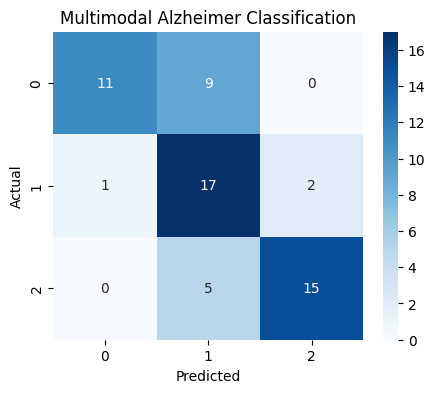

In [24]:
cm = confusion_matrix(y_test,pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm,annot=True,fmt='d',cmap="Blues")

plt.title("Multimodal Alzheimer Classification")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()